In [2]:
import pandas as pd
import re
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
data_path = "tweets-data\sentiment-spanish.csv"
prepro_data_path = "tweets-data\hasilpreprocess-spanish.csv"

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Asus\AppData\Local\Temp\ipykernel_17628\1604370792.py:1: SyntaxWarning: invalid escape sequence '\s'
  data_path = "tweets-data\sentiment-spanish.csv"
C:\Users\Asus\AppData\Local\Temp\ipykernel_17628\1604370792.py:2: SyntaxWarning: invalid escape sequence '\h'
  prepro_data_path = "tweets-data\hasilpreprocess-spanish.csv"


In [4]:
data = pd.read_csv(data_path)

In [5]:
data.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1893345123896791101,Sun Feb 23 17:34:57 +0000 2025,0,@Encu5Futbol 🇦🇷Boca 🇪🇦Real Madrid 󠁧󠁢󠁥󠁮󠁧󠁿Manche...,1893716187701182968,NaN,Encu5Futbol,es,NaN,0,0,0,https://x.com/_elfamosoriver/status/1893716187...,1891714004487159808,_elfamosoriver
1,1893532236797903023,Sun Feb 23 17:34:34 +0000 2025,0,@arielipillo Pa verdad no creo que chistiano l...,1893716092465381847,NaN,arielipillo,es,NaN,0,0,0,https://x.com/rodri2582/status/189371609246538...,1576228196,rodri2582
2,1893715752273735868,Sun Feb 23 17:33:16 +0000 2025,0,El Manchester City debe ver lo ocurrido con el...,1893715766484115791,NaN,LuisVala10,es,Mexico,0,1,0,https://x.com/LuisVala10/status/18937157664841...,1095518262039904256,LuisVala10
3,1893714859579076711,Sun Feb 23 17:29:40 +0000 2025,0,: Manchester United se repuso de una desventaj...,1893714859579076711,https://pbs.twimg.com/media/GkfToQTbEAATNBD.jpg,NaN,es,"Torreón, Coahuila de Zaragoza",0,0,0,https://x.com/josejuangelmx/status/18937148595...,1132664972079783936,josejuangelmx
4,1893445997251985645,Sun Feb 23 17:29:32 +0000 2025,0,@KTenmac @Cr7stianismo_ Ganó una champions con...,1893714824682443056,NaN,KTenmac,es,"Brownsville, TX",0,0,0,https://x.com/elbrando956/status/1893714824682...,1847025412443930624,elbrando956


In [6]:
df = data[['full_text', 'username', 'created_at']]
df

,full_text,username,created_at
0,@Encu5Futbol 🇦🇷Boca 🇪🇦Real Madrid 󠁧󠁢󠁥󠁮󠁧󠁿Manche...,_elfamosoriver,Sun Feb 23 17:34:57 +0000 2025
1,@arielipillo Pa verdad no creo que chistiano l...,rodri2582,Sun Feb 23 17:34:34 +0000 2025
2,El Manchester City debe ver lo ocurrido con el...,LuisVala10,Sun Feb 23 17:33:16 +0000 2025
3,: Manchester United se repuso de una desventaj...,josejuangelmx,Sun Feb 23 17:29:40 +0000 2025
4,@KTenmac @Cr7stianismo_ Ganó una champions con...,elbrando956,Sun Feb 23 17:29:32 +0000 2025
...,...,...,...
1012,Manchester United precisa acabar!,gui_valeriano04,Sat Feb 22 13:23:40 +0000 2025
1013,Da pena como han destruido un club tan grande ...,Robportiz24,Sat Feb 22 13:23:30 +0000 2025
1014,Ebembe ya Manchester United https://t.co/aob41...,twittozairois,Sat Feb 22 13:23:25 +0000 2025
1015,En el everton tenemos ya muchos verdes pero si...,futbolpremierl,Sat Feb 22 13:23:23 +0000 2025


# 1. Cleaning Data

In [7]:
df.shape

(1017, 3)

In [8]:
df = df.drop_duplicates(subset=['full_text'])

In [9]:
df.duplicated().sum()

0

In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

full_text     0
username      0
created_at    0
dtype: int64

In [12]:
df.shape

(1016, 3)

In [13]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'RT[\s]+', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^A-Za-z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['full_text'] = df['full_text'].apply(clean_twitter_text)

In [14]:
df['full_text'] = df['full_text'].str.lower()

In [15]:
df

,full_text,username,created_at
0,boca real madrid manchester united juventus fl...,_elfamosoriver,Sun Feb 23 17:34:57 +0000 2025
1,pa verdad no creo que chistiano llorando sea c...,rodri2582,Sun Feb 23 17:34:34 +0000 2025
2,el manchester city debe ver lo ocurrido con el...,LuisVala10,Sun Feb 23 17:33:16 +0000 2025
3,manchester united se repuso de una desventaja ...,josejuangelmx,Sun Feb 23 17:29:40 +0000 2025
4,gan una champions con manchester united,elbrando956,Sun Feb 23 17:29:32 +0000 2025
...,...,...,...
1012,manchester united precisa acabar,gui_valeriano04,Sat Feb 22 13:23:40 +0000 2025
1013,da pena como han destruido un club tan grande ...,Robportiz24,Sat Feb 22 13:23:30 +0000 2025
1014,ebembe ya manchester united,twittozairois,Sat Feb 22 13:23:25 +0000 2025
1015,en el everton tenemos ya muchos verdes pero si...,futbolpremierl,Sat Feb 22 13:23:23 +0000 2025


# 2. Preprocessing

- Normalisasi
- Stopword
- Tokenize
- Stemming

In [16]:
# Normalisasi

norm = {
    "pa": "para", "q": "que", "xq": "por qué", "xd": "(risa)",
    "chistiano": "Cristiano", "ganóo": "ganó", "k": "que", "d": "de",
    "tmb": "también", "pq": "porque", "bn": "bien", "tb": "también",
    "asi": "así", "sta": "está", "va": "vaya", "aki": "aquí",
    "toy": "estoy", "mñn": "mañana", "hpta": "hijueputa"
}

def normalisasi(str_text):
    for i in norm:
        str_text = str_text.replace(i, norm[i])
    return str_text

df['full_text'] = df['full_text'].apply(lambda x: normalisasi(x))
df

,full_text,username,created_at
0,boca real maderide manchester unitede juventus...,_elfamosoriver,Sun Feb 23 17:34:57 +0000 2025
1,para verdeade no creo queue Cristiano llorande...,rodri2582,Sun Feb 23 17:34:34 +0000 2025
2,el manchester city deebe ver lo ocurrideo con ...,LuisVala10,Sun Feb 23 17:33:16 +0000 2025
3,manchester unitede se repuso dee una deesventa...,josejuangelmx,Sun Feb 23 17:29:40 +0000 2025
4,gan una champions con manchester unitede,elbrando956,Sun Feb 23 17:29:32 +0000 2025
...,...,...,...
1012,manchester unitede precisa acabar,gui_valeriano04,Sat Feb 22 13:23:40 +0000 2025
1013,dea pena como han deestruideo un club tan gran...,Robportiz24,Sat Feb 22 13:23:30 +0000 2025
1014,ebembe ya manchester unitede,twittozairois,Sat Feb 22 13:23:25 +0000 2025
1015,en el everton tenemos ya muchos verdees pero s...,futbolpremierl,Sat Feb 22 13:23:23 +0000 2025


In [17]:
# Stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

manual_stop_words = [
    'el', 'de', 'que', 'en', 'y', 'la', 'a', 'un', 'del', 'no', 'los', 'es', 
    'al', 'se', 'con', 'lo', 'por', 'pero', 'más', 'una', 'su', 'le', 'ante', 
    'me', 'como', 'este', 'las', 'está', 'o', 'contra', 'hay', 'ya', 'sin', 
    'tiene', 'ni', 'todo', 'ha', 'fue', 'son', 'nada', 'hace', 'eso', 'cuando'
]

nltk_stop_words = set(stopwords.words('spanish'))
custom_stop_words = nltk_stop_words.union(set(manual_stop_words))

def remove_stopwords_manual(str_text):
    words = str_text.split()
    filtered_words = [word for word in words if word.lower() not in manual_stop_words]
    return " ".join(filtered_words)

df['full_text'] = df['full_text'].apply(remove_stopwords_manual)

df[['full_text']]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,full_text
0,boca real maderide manchester unitede juventus...
1,para verdeade creo queue Cristiano llorandeo s...
2,manchester city deebe ver ocurrideo nulo cambi...
3,manchester unitede repuso dee deesventaja dee ...
4,gan champions manchester unitede
...,...
1012,manchester unitede precisa acabar
1013,dea pena han deestruideo club tan grandee manc...
1014,ebembe manchester unitede
1015,everton tenemos muchos verdees si manchester u...


In [18]:
# Tokenize
tokenized = df['full_text'].apply(lambda x:x.split())
tokenized

0       [boca, real, maderide, manchester, unitede, ju...
1       [para, verdeade, creo, queue, Cristiano, llora...
2       [manchester, city, deebe, ver, ocurrideo, nulo...
3       [manchester, unitede, repuso, dee, deesventaja...
4                   [gan, champions, manchester, unitede]
                              ...                        
1012               [manchester, unitede, precisa, acabar]
1013    [dea, pena, han, deestruideo, club, tan, grand...
1014                        [ebembe, manchester, unitede]
1015    [everton, tenemos, muchos, verdees, si, manche...
1016    [ordeen, ganas, efectivideade, everton, ms, qu...
Name: full_text, Length: 1016, dtype: object

In [19]:
import nltk
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

df['full_text'] = df['full_text'].apply(stemming)
tokenized.to_csv(prepro_data_path, index=False)
data = pd.read_csv(prepro_data_path, encoding='latin1')


# 3. Labeling

In [20]:
data

,full_text
0,"['boca', 'real', 'maderide', 'manchester', 'un..."
1,"['para', 'verdeade', 'creo', 'queue', 'Cristia..."
2,"['manchester', 'city', 'deebe', 'ver', 'ocurri..."
3,"['manchester', 'unitede', 'repuso', 'dee', 'de..."
4,"['gan', 'champions', 'manchester', 'unitede']"
...,...
1011,"['manchester', 'unitede', 'precisa', 'acabar']"
1012,"['dea', 'pena', 'han', 'deestruideo', 'club', ..."
1013,"['ebembe', 'manchester', 'unitede']"
1014,"['everton', 'tenemos', 'muchos', 'verdees', 's..."


In [21]:
import preprocessor as p 
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('movie_reviews')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
data_tweet = list(data['full_text'])
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, tweet in enumerate(data_tweet):
    analysis = TextBlob(tweet)
    polaritas += analysis.polarity

    if analysis.sentiment.polarity > 0.0:
        total_positif +=1
        status.append('Positif')
    elif analysis.sentiment.polarity == 0.0:
        total_netral += 1
        status.append('Netral')
    else:
        total_negatif += 1
        status.append('Negatif')

    total += 1

print(f"Hasil Analisis Data :\nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}")
print(f"\nTotal Data : {total}")

Hasil Analisis Data :
Positif = 69
Netral = 927
Negatif = 20

Total Data : 1016


In [23]:
data['klasifikasi'] = status
data

,full_text,klasifikasi
0,"['boca', 'real', 'maderide', 'manchester', 'un...",Positif
1,"['para', 'verdeade', 'creo', 'queue', 'Cristia...",Netral
2,"['manchester', 'city', 'deebe', 'ver', 'ocurri...",Netral
3,"['manchester', 'unitede', 'repuso', 'dee', 'de...",Netral
4,"['gan', 'champions', 'manchester', 'unitede']",Netral
...,...,...
1011,"['manchester', 'unitede', 'precisa', 'acabar']",Netral
1012,"['dea', 'pena', 'han', 'deestruideo', 'club', ...",Netral
1013,"['ebembe', 'manchester', 'unitede']",Netral
1014,"['everton', 'tenemos', 'muchos', 'verdees', 's...",Netral


# 4. Visualisasi

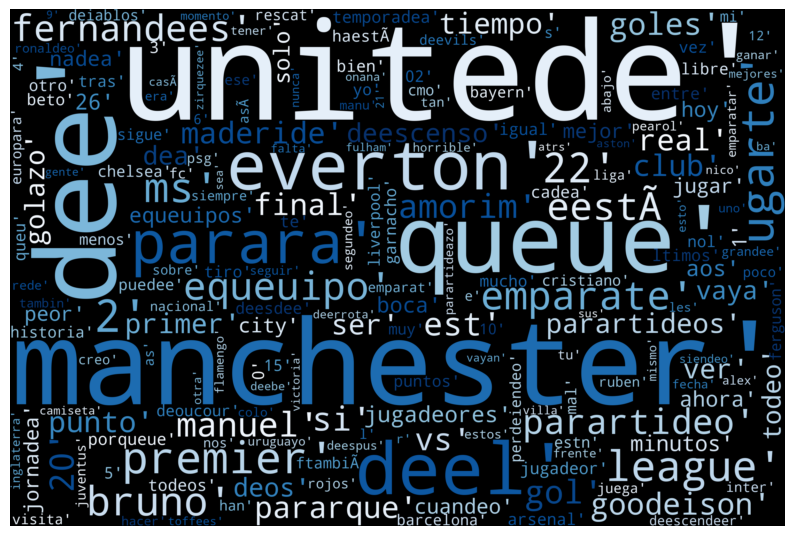

In [24]:
from wordcloud import WordCloud, STOPWORDS

def plot_cloud(wordcloud):
    plt.figure(figsize=(10,8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

all_words = ' '.join([tweets for tweets in data['full_text']])

Wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Blues_r',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_words)

plot_cloud(Wordcloud)

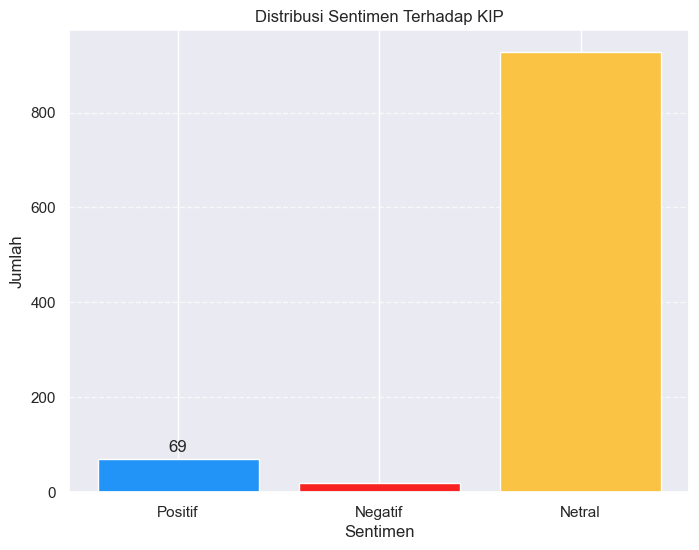

In [25]:
import seaborn as sns

sns.set_theme()

labels = ['Positif','Negatif','Netral']
counts =[total_positif,total_negatif,total_netral]

def show_bar_chart(labels, counts, title):
    fig, ax = plt.subplots(figsize=(8,6))
    bars = ax.bar(labels, counts, color=['#2394f7','#f72323','#fac343'])

    for bar, count in zip(bars,counts):
        height = bar.get_height()
        ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        ax.set_xlabel('Sentimen')
        ax.set_ylabel('Jumlah')
        ax.set_title(title)

        plt.show()

show_bar_chart(labels,counts,"Distribusi Sentimen Terhadap KIP")

# 5. Multinomial Naive Bayes

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

In [27]:
data.head()

,full_text,klasifikasi
0,"['boca', 'real', 'maderide', 'manchester', 'un...",Positif
1,"['para', 'verdeade', 'creo', 'queue', 'Cristia...",Netral
2,"['manchester', 'city', 'deebe', 'ver', 'ocurri...",Netral
3,"['manchester', 'unitede', 'repuso', 'dee', 'de...",Netral
4,"['gan', 'champions', 'manchester', 'unitede']",Netral


In [28]:
data.shape

(1016, 2)

In [29]:
data.klasifikasi.unique()

array(['Positif', 'Netral', 'Negatif'], dtype=object)

In [30]:
data.klasifikasi.value_counts()

klasifikasi
Netral     927
Positif     69
Negatif     20
Name: count, dtype: int64

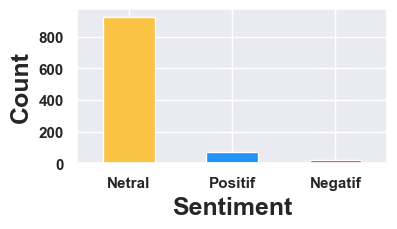

In [31]:
data.klasifikasi.value_counts().plot(kind='bar', figsize=(4, 2), rot=0, color=['#fac343', '#2394f7', '#f72323'])
plt.xlabel('Sentiment', fontweight='bold', fontsize=18)
plt.ylabel('Count', fontweight='bold', fontsize=18)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold');

In [32]:
labelencoder = LabelEncoder()
data['Target'] = labelencoder.fit_transform(data['klasifikasi'])

In [33]:
data.Target.unique()

array([2, 1, 0])

In [34]:
X = data.full_text
y = data.Target

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

In [36]:
len(X_train), len(X_test), len(y_train), len(y_test)

(812, 204, 812, 204)

In [37]:
clf = Pipeline([
    ('cv', CountVectorizer()),
    ('mnb', MultinomialNB(force_alpha=False))
])

In [38]:
clf.fit(X_train, y_train)

Pipeline(steps=[('cv', CountVectorizer()),
                ('mnb', MultinomialNB(force_alpha=False))])

In [39]:
print('Accuracy on the test set:', round(clf.score(X_test, y_test), 4))

Accuracy on the test set: 0.9265


In [40]:
y_pred = clf.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=clf.classes_)

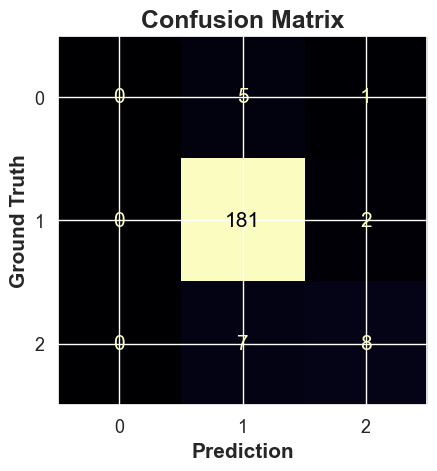

In [41]:

disp.plot(cmap='magma', colorbar=False, text_kw={'size': 15})

plt.xlabel('Prediction', fontsize=15, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13);

In [42]:
cat_labels = ['negative', 'neutral', 'positive']
y_pred = clf.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=cat_labels)

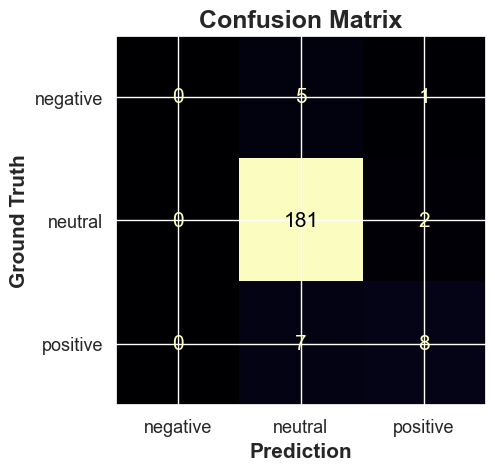

In [43]:
disp.plot(cmap='magma', colorbar=False, text_kw={'size': 15})

plt.xlabel('Prediction', fontsize=15, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13);

In [44]:
print('F1 score:', round(metrics.f1_score(y_test, y_pred, average='micro'), 4))

F1 score: 0.9265


In [45]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.94      0.99      0.96       183
           2       0.73      0.53      0.62        15

    accuracy                           0.93       204
   macro avg       0.56      0.51      0.53       204
weighted avg       0.89      0.93      0.91       204



c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

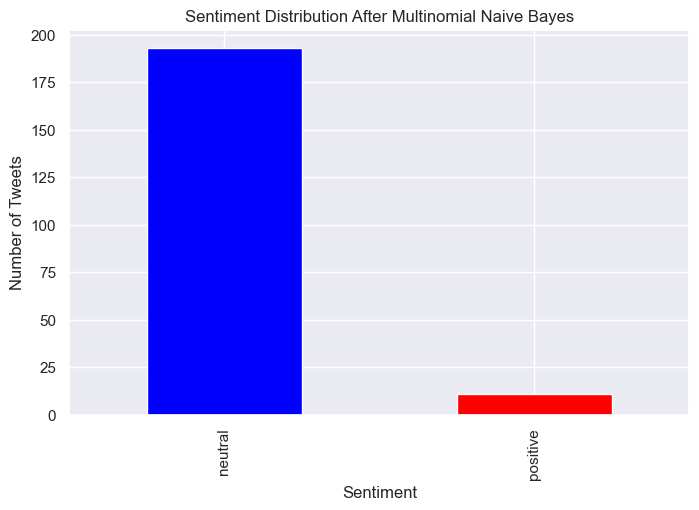

In [46]:
df_result = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
df_result['Predicted'] = df_result['Predicted'].map(label_mapping)

sentiment_count = df_result['Predicted'].value_counts()

plt.figure(figsize=(8,5))
sentiment_count.plot(kind='bar', color=['blue', 'red', 'yellow'])
plt.title('Sentiment Distribution After Multinomial Naive Bayes')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()